# Klassifikation von Kundenservice-Anfragen: ML-Prototyp

Dieses Notebook bildet die bereinigte Arbeitsgrundlage des Prototyps und enthält ausschließlich jene
Bestandteile, die sich im Verlauf der explorativen Vorarbeiten als tragfähig erwiesen haben. Als
Datenbasis dient der mehrsprachige Datensatz *multilingual-customer-support-tickets*, dessen
Eignung gegenüber den zuvor geprüften Alternativen darin besteht, dass die hinterlegten Labels einen
inhaltlich nachvollziehbaren Bezug zum Anfragetext aufweisen und somit überhaupt erst eine sinnvoll
erlernbare Zielgröße bereitstellen.

Der Ablauf gliedert sich in das Laden und die Sichtung der Daten, die Erzeugung semantischer
Textrepräsentationen mittels Sentence-Embeddings, ein erstes Klassifikationsmodell als
Vergleichsmaßstab sowie die anschließende, gezielte Überarbeitung des Kategorieschemas, mit der die
im Baseline-Modell erkannten Schwächen adressiert werden.

## Imports

Diese Zelle ist stets zuerst auszuführen, da sämtliche nachfolgenden Schritte auf den hier eingebundenen Bibliotheken aufsetzen.

In [1]:
import os

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sentence_transformers import SentenceTransformer
from xgboost import XGBClassifier

c:\Users\Julius\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Datensatz laden

Der Datensatz wird über `kagglehub` bezogen, das die Daten lokal zwischenspeichert und den Pfad zum
Ablageverzeichnis zurückgibt. Auf diesen Pfad greifen die folgenden Schritte zu.

In [2]:
# Lädt die aktuelle Version des Datensatzes herunter (bzw. nutzt den lokalen Cache)
# und gibt das Verzeichnis zurück, in dem die Dateien abgelegt sind.
path = kagglehub.dataset_download("tobiasbueck/multilingual-customer-support-tickets")

print("Pfad zu den Datensatzdateien:", path)
csv_path = os.path.join(path, "dataset-tickets-multi-lang-4-20k.csv")
df_multilingual = pd.read_csv(csv_path)

print(f"Geladene Datei : {csv_path}")
print(f"Zeilen gesamt  : {len(df_multilingual)}")
df_multilingual.head()
print("\n--- Info ---")
df_multilingual.info()


Pfad zu den Datensatzdateien: C:\Users\Julius\.cache\kagglehub\datasets\tobiasbueck\multilingual-customer-support-tickets\versions\14
Geladene Datei : C:\Users\Julius\.cache\kagglehub\datasets\tobiasbueck\multilingual-customer-support-tickets\versions\14\dataset-tickets-multi-lang-4-20k.csv
Zeilen gesamt  : 20000

--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   subject   18539 non-null  str  
 1   body      19998 non-null  str  
 2   answer    19996 non-null  str  
 3   type      20000 non-null  str  
 4   queue     20000 non-null  str  
 5   priority  20000 non-null  str  
 6   language  20000 non-null  str  
 7   tag_1     20000 non-null  str  
 8   tag_2     19954 non-null  str  
 9   tag_3     19905 non-null  str  
 10  tag_4     18461 non-null  str  
 11  tag_5     13091 non-null  str  
 12  tag_6     7351 non-null   str  
 13  tag_7     392

## Sichtung des Datensatzes

Vor jeder Modellierung wird der Datenbestand zunächst beschrieben, um Wertebereiche, fehlende
Einträge und die Verteilung der späteren Zielvariablen einschätzen zu können.

In [3]:
df_multilingual.describe(include='all')

,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
count,18539,19998,19996,20000,20000,20000,20000,20000,19954,19905,18461,13091,7351,3928,1907
unique,18539,19998,19996,4,10,3,2,148,204,344,481,578,566,492,386
top,Unvorhergesehener Absturz der Datenanalyse-Pla...,Die Datenanalyse-Plattform brach unerwartet ab...,Ich werde Ihnen bei der Lösung des Problems he...,Incident,Technical Support,medium,en,Technical,Performance,IT,Tech Support,Tech Support,Resolution,Resolution,Documentation
freq,1,1,1,7978,5824,8144,11923,5034,2795,3309,3436,2287,841,417,162


### Verteilung der Kategorien

Betrachtet wird die Verteilung der Tickets über die Spalte `queue`, die als Zielvariable dient und die
fachliche Warteschlange (also die zuständige Bearbeitungskategorie) angibt, ergänzt um die Verteilung
nach `business_type`. Bereits diese Übersicht macht ein deutliches Klassenungleichgewicht sichtbar,
das für die spätere Interpretation der Modellgüte von Bedeutung ist.

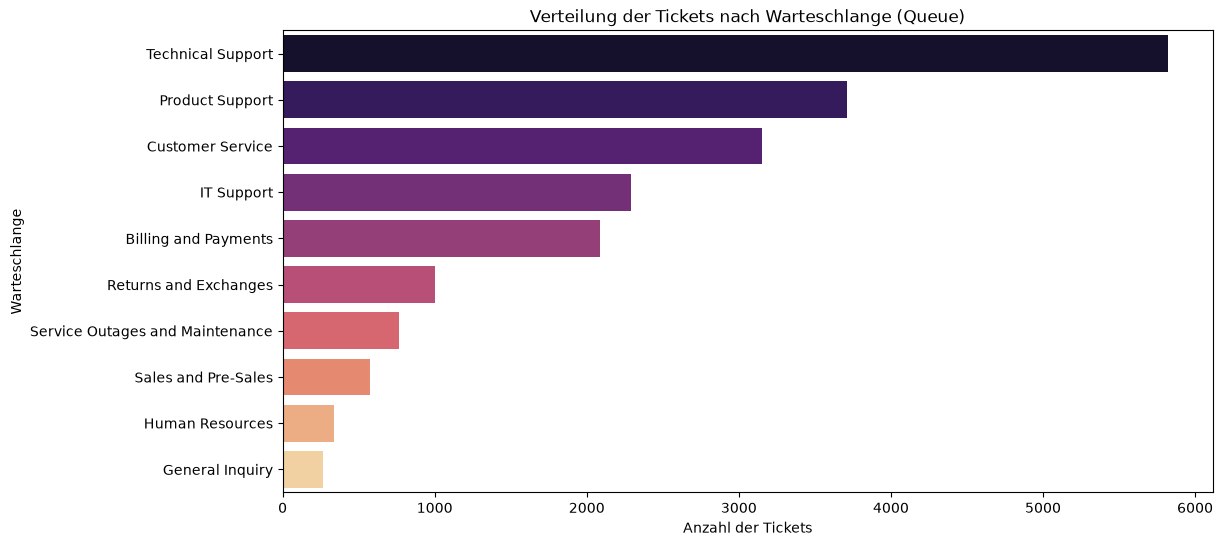

In [4]:
# Verteilung der Tickets nach Warteschlange (Zielvariable)
plt.figure(figsize=(12, 6))
queue_counts = df_multilingual['queue'].value_counts()
sns.barplot(x=queue_counts.values, y=queue_counts.index, palette='magma', hue=queue_counts.index, legend=False)
plt.title('Verteilung der Tickets nach Warteschlange (Queue)')
plt.xlabel('Anzahl der Tickets')
plt.ylabel('Warteschlange')
plt.show()

## Erzeugung der Sentence-Embeddings

Als Eingabemerkmal dient der zusammengeführte Text aus Betreff (`subject`) und Nachrichtentext
(`body`), womit die Merkmalsbildung mit jener der übrigen untersuchten Ansätze übereinstimmt und der
Betreff als häufig prägnanteste Verdichtung des Anliegens dem Modell nicht vorenthalten wird. Dieser
kombinierte Text wird mit dem vortrainierten Modell `all-MiniLM-L6-v2` in dichte
Vektorrepräsentationen überführt, welche die semantische Ähnlichkeit der Anfragen abbilden und
sämtlichen Klassifikatoren als Grundlage dienen. Da die Einbettung über den gesamten Textkorpus
rechenintensiv ausfällt, wird sie nur einmal berechnet und in den nachfolgenden Modellschritten
wiederverwendet.

In [5]:
# Vortrainiertes, kompaktes Embedding-Modell laden.
model = SentenceTransformer('all-MiniLM-L6-v2')

# Betreff und Nachrichtentext werden zu einem gemeinsamen Eingabetext verbunden.
# Fehlende Einträge in einer der beiden Spalten werden durch leere Zeichenketten
# ersetzt, damit jede Zeile verarbeitet werden kann, und beide Felder werden
# explizit in Zeichenketten umgewandelt. Der zusammengesetzte Text wird als eigene
# Spalte abgelegt, sodass alle nachfolgenden Schritte auf dieselbe Merkmalsbasis
# zugreifen.
df_multilingual['text_feature'] = (
    df_multilingual['subject'].fillna('').astype(str)
    + '. '
    + df_multilingual['body'].fillna('').astype(str)
)

texts = df_multilingual['text_feature'].tolist()

# Der Textkorpus wird stapelweise kodiert; der Fortschrittsbalken erlaubt eine
# Abschätzung der verbleibenden Laufzeit bei umfangreichen Datenmengen.
embeddings = model.encode(
    texts,
    batch_size=256,
    show_progress_bar=True
)

Batches: 100%|██████████| 79/79 [10:31<00:00,  7.99s/it]


## Baseline-Modell: Klassifikation der Warteschlange

Als Ausgangspunkt wird ein XGBoost-Klassifikator auf den unveränderten Kategorien trainiert. Dieses
Modell dient nicht als finale Lösung, sondern als Vergleichsmaßstab, an dem sich der Nutzen der
anschließenden Überarbeitung des Kategorieschemas bemessen lässt. Der stratifizierte Train-Test-Split
stellt sicher, dass die Klassenverhältnisse in Trainings- und Testmenge erhalten bleiben.

In [6]:
# Die textuellen Kategoriebezeichnungen werden in ganzzahlige Labels überführt,
# da XGBoost numerische Zielwerte erwartet.
le_queue = LabelEncoder()
y_multilingual = le_queue.fit_transform(df_multilingual['queue'])

# Aufteilung in Trainings- und Testmenge (80/20). 'stratify' erhält die
# Klassenverteilung in beiden Teilmengen, was bei unausgewogenen Daten wichtig ist.
X_train, X_test, y_train, y_test = train_test_split(
    embeddings,
    y_multilingual,
    test_size=0.2,
    random_state=42,
    stratify=y_multilingual
)

# XGBoost-Klassifikator. 'multi:softprob' liefert Wahrscheinlichkeiten je Klasse,
# 'n_jobs=-1' nutzt alle verfügbaren CPU-Kerne.
xgb_multi_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    objective='multi:softprob',
    n_jobs=-1,
    random_state=42
)

print("Training des XGBoost-Modells läuft...")
xgb_multi_model.fit(X_train, y_train)

# Vorhersage auf der Testmenge und ausführliche Bewertung je Klasse.
y_pred = xgb_multi_model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le_queue.classes_))

Training des XGBoost-Modells läuft...

Classification Report:
                                 precision    recall  f1-score   support

           Billing and Payments       0.83      0.69      0.75       417
               Customer Service       0.35      0.36      0.35       630
                General Inquiry       1.00      0.04      0.07        53
                Human Resources       0.87      0.19      0.31        68
                     IT Support       0.54      0.15      0.24       458
                Product Support       0.41      0.34      0.37       742
          Returns and Exchanges       0.68      0.12      0.20       200
            Sales and Pre-Sales       0.71      0.09      0.16       114
Service Outages and Maintenance       0.76      0.25      0.37       153
              Technical Support       0.42      0.78      0.55      1165

                       accuracy                           0.46      4000
                      macro avg       0.66      0.30      0.

### Fehleranalyse anhand der Konfusionsmatrix

Die Konfusionsmatrix stellt die tatsächlichen den vorhergesagten Kategorien gegenüber und legt damit
systematische Verwechslungen offen.

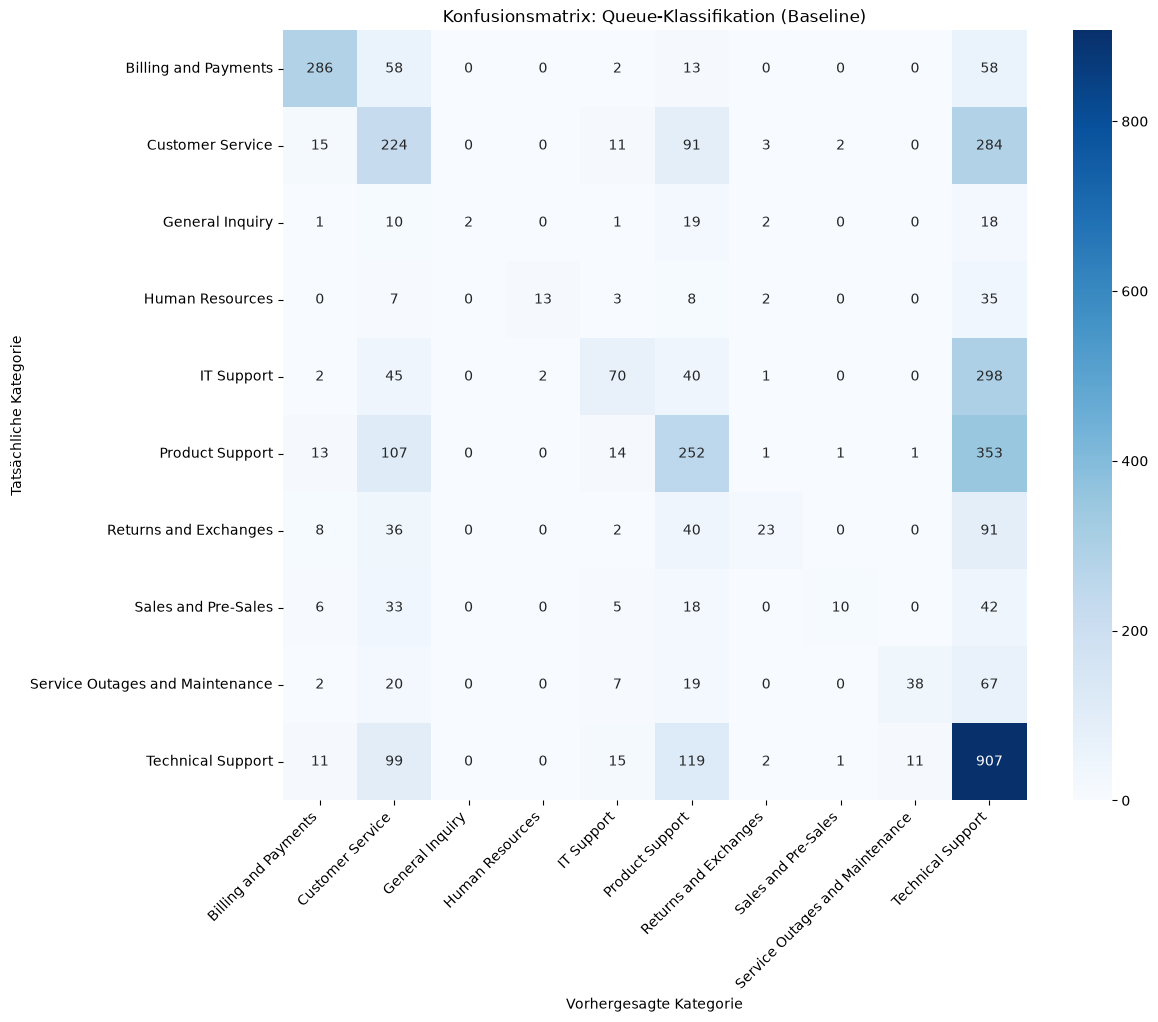

In [7]:
# Konfusionsmatrix der Baseline. Zeilen entsprechen den tatsächlichen,
# Spalten den vorhergesagten Kategorien.
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le_queue.classes_,
    yticklabels=le_queue.classes_
)
plt.title('Konfusionsmatrix: Queue-Klassifikation (Baseline)')
plt.ylabel('Tatsächliche Kategorie')
plt.xlabel('Vorhergesagte Kategorie')
plt.xticks(rotation=45, ha='right')
plt.show()

Die Auswertung des Baseline-Modells offenbart mehrere zusammenhängende Schwächen. Ein erheblicher
Anteil der Tickets aus den Kategorien *IT Support*, *Customer Service* und *Product Support* wird
fälschlich der Kategorie *Technical Support* zugeordnet, wobei das Modell im Zweifelsfall die
frequenzstärkste Klasse bevorzugt, was ein typisches Symptom ausgeprägten Klassenungleichgewichts darstellt.
Besonders deutlich tritt dies bei *Human Resources* hervor, für das praktisch keine korrekte
Vorhersage gelingt und dessen Recall gegen null tendiert. Demgegenüber heben sich *Billing and
Payments* sowie *Returns and Exchanges* mit einer vergleichsweise klaren Diagonale ab, was darauf
hindeutet, dass sich diese Themen inhaltlich trennschärfer von den rein technischen Anliegen
abgrenzen lassen.

## Überarbeitung des Kategorieschemas

Aus der Fehleranalyse ergeben sich zwei gezielte Eingriffe, mit denen den festgestellten Schwächen
begegnet wird. Zum einen werden inhaltlich eng verwandte und vom Modell ohnehin kaum trennbare
Kategorien zu jeweils einer übergeordneten Klasse zusammengeführt; insbesondere *IT Support* und
*Technical Support* beschreiben aus Sicht des Anfragetextes weitgehend dasselbe Anliegen, sodass ihre
Trennung mehr Rauschen als Information erzeugt. Zum anderen wird die Kategorie *Human Resources*
vollständig aus dem Datensatz entfernt, da sie sowohl zu schwach besetzt ist als auch thematisch kaum
Mehrwert für ein auf Kundenanliegen ausgerichtetes Klassifikationssystem bietet.

Das Zusammenführen reduziert das Klassenungleichgewicht und schärft die verbleibenden Klassengrenzen,
während das Entfernen der unbrauchbaren Restklasse verhindert, dass das Modell Kapazität auf eine
praktisch nicht erlernbare Kategorie verwendet. Das Mapping ist bewusst defensiv formuliert: Es wirkt
nur auf tatsächlich vorhandene Kategorien, sodass geringfügige Abweichungen in den Bezeichnungen des
Datensatzes nicht zu Fehlern führen.

In [8]:
# Ausgangsbestand sichern und die im Datensatz vorhandenen Kategorien ausgeben.
print("Vorhandene Kategorien vor der Überarbeitung:")
print(df_multilingual['queue'].value_counts(), "\n")

# Zusammenführung inhaltlich verwandter Kategorien. Schlüssel ist die
# ursprüngliche, Wert die gebündelte Zielbezeichnung. Nur Kategorien, die
# tatsächlich auftreten, werden umgeschrieben; alle übrigen bleiben unverändert.
category_merge_map = {
    'IT Support': 'Technical and IT Support',
    'Technical Support': 'Technical and IT Support',
}

# Kategorien, die vollständig entfernt werden, weil sie zu schwach besetzt sind
# und thematisch keinen Mehrwert für die Klassifikation von Kundenanliegen bieten.
categories_to_drop = ['Human Resources']

df_clean = df_multilingual.copy()

# Zusammenführung anwenden: 'replace' ersetzt ausschließlich die im Mapping
# genannten Werte, sodass nicht aufgeführte Kategorien erhalten bleiben.
df_clean['queue'] = df_clean['queue'].replace(category_merge_map)

# Zu schwache Kategorien herausfiltern.
df_clean = df_clean[~df_clean['queue'].isin(categories_to_drop)].reset_index(drop=True)

print("Kategorien nach der Überarbeitung:")
print(df_clean['queue'].value_counts())

Vorhandene Kategorien vor der Überarbeitung:
queue
Technical Support                  5824
Product Support                    3708
Customer Service                   3152
IT Support                         2292
Billing and Payments               2086
Returns and Exchanges              1001
Service Outages and Maintenance     764
Sales and Pre-Sales                 572
Human Resources                     338
General Inquiry                     263
Name: count, dtype: int64 

Kategorien nach der Überarbeitung:
queue
Technical and IT Support           8116
Product Support                    3708
Customer Service                   3152
Billing and Payments               2086
Returns and Exchanges              1001
Service Outages and Maintenance     764
Sales and Pre-Sales                 572
General Inquiry                     263
Name: count, dtype: int64


### Anpassung der Embeddings an den bereinigten Datensatz

Da durch das Entfernen der Kategorie *Human Resources* einzelne Zeilen wegfallen, muss die zuvor
berechnete Embedding-Matrix auf dieselben Zeilen eingeschränkt werden. Genutzt wird hierfür der
Original-Index der erhaltenen Zeilen, sodass eine erneute, rechenintensive Einbettung entfällt und die
Zuordnung zwischen Merkmalen und Labels konsistent bleibt.

In [9]:
# 'embeddings' wurde in Zeilenreihenfolge des ursprünglichen DataFrames berechnet.
# Vor dem Zurücksetzen des Index merken wir uns, welche Originalzeilen erhalten
# bleiben, und wählen daraus die passenden Embedding-Zeilen aus.
embeddings = np.asarray(embeddings)

# Maske der beibehaltenen Zeilen auf Basis des ursprünglichen DataFrames.
kept_mask = ~df_multilingual['queue'].replace(category_merge_map).isin(categories_to_drop)
embeddings_clean = embeddings[kept_mask.to_numpy()]

print("Form der Embeddings vor der Bereinigung:", embeddings.shape)
print("Form der Embeddings nach der Bereinigung:", embeddings_clean.shape)
print("Anzahl der Zeilen im bereinigten DataFrame:", len(df_clean))

Form der Embeddings vor der Bereinigung: (20000, 384)
Form der Embeddings nach der Bereinigung: (19662, 384)
Anzahl der Zeilen im bereinigten DataFrame: 19662


### Erneutes Training auf dem überarbeiteten Kategorieschema

Mit identischer Modellkonfiguration wie im Baseline-Schritt wird der Klassifikator nun auf den
gebündelten und bereinigten Kategorien trainiert. Die Beibehaltung der Hyperparameter stellt sicher,
dass beobachtete Verbesserungen auf das überarbeitete Schema und nicht auf abweichende
Modelleinstellungen zurückzuführen sind.

In [10]:
# Zielvariable des bereinigten Datensatzes neu kodieren.
le_queue_clean = LabelEncoder()
y_clean = le_queue_clean.fit_transform(df_clean['queue'])

# Stratifizierter Train-Test-Split auf den bereinigten Daten.
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    embeddings_clean,
    y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)

# Gleiche Konfiguration wie das Baseline-Modell, um einen fairen Vergleich zu ermöglichen.
xgb_clean_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    objective='multi:softprob',
    n_jobs=-1,
    random_state=42
)

print("Training des überarbeiteten Modells läuft...")
xgb_clean_model.fit(X_train_c, y_train_c)

y_pred_c = xgb_clean_model.predict(X_test_c)

print("\nClassification Report (überarbeitetes Schema):")
print(classification_report(y_test_c, y_pred_c, target_names=le_queue_clean.classes_))

Training des überarbeiteten Modells läuft...

Classification Report (überarbeitetes Schema):
                                 precision    recall  f1-score   support

           Billing and Payments       0.88      0.65      0.75       417
               Customer Service       0.42      0.27      0.33       631
                General Inquiry       1.00      0.06      0.11        53
                Product Support       0.50      0.25      0.34       742
          Returns and Exchanges       0.68      0.07      0.12       200
            Sales and Pre-Sales       1.00      0.04      0.07       114
Service Outages and Maintenance       0.87      0.22      0.35       153
       Technical and IT Support       0.53      0.91      0.67      1623

                       accuracy                           0.55      3933
                      macro avg       0.74      0.31      0.34      3933
                   weighted avg       0.58      0.55      0.50      3933



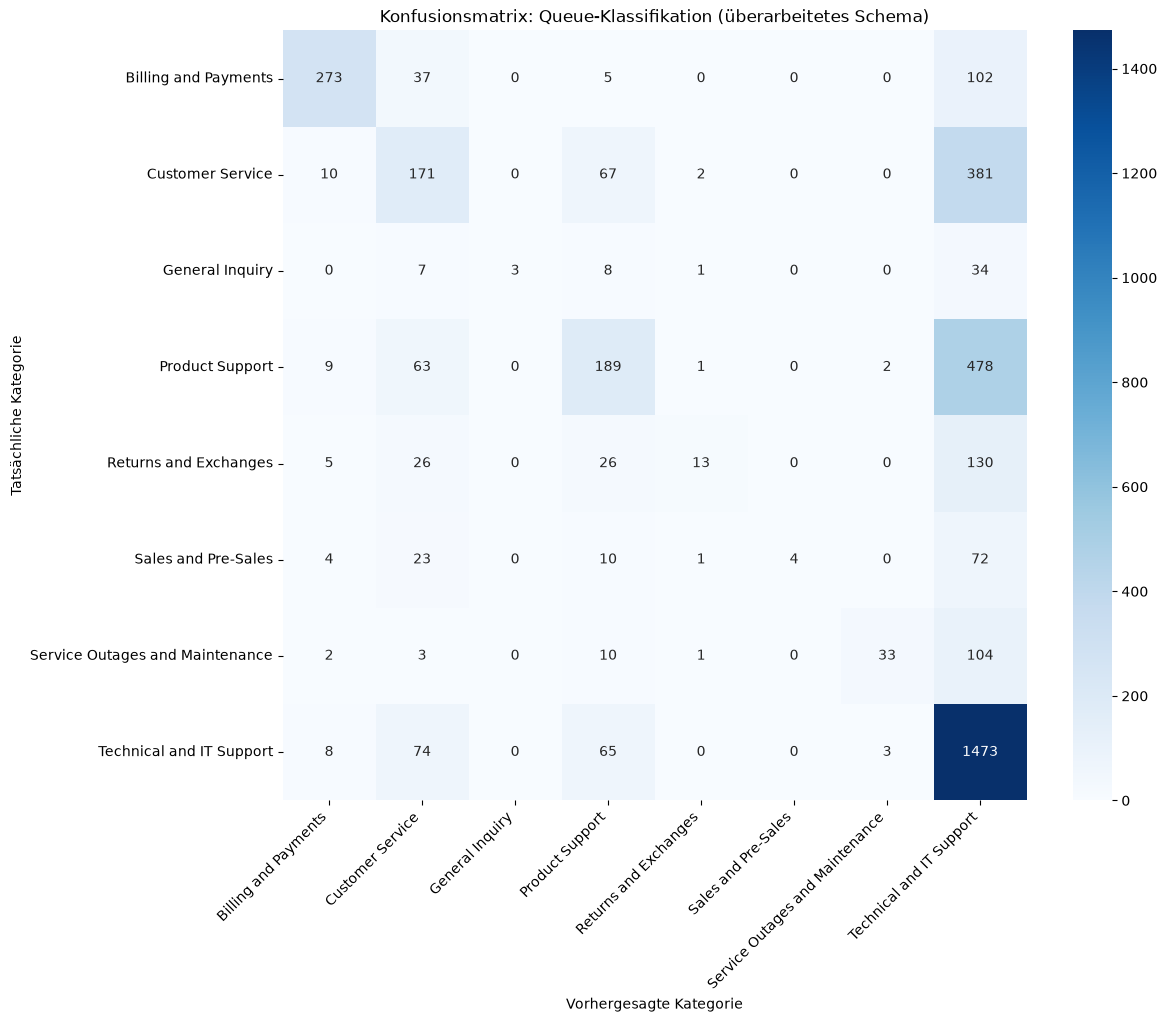

In [11]:
# Konfusionsmatrix des überarbeiteten Modells zur direkten Gegenüberstellung
# mit der Baseline.
cm_clean = confusion_matrix(y_test_c, y_pred_c)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_clean,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le_queue_clean.classes_,
    yticklabels=le_queue_clean.classes_
)
plt.title('Konfusionsmatrix: Queue-Klassifikation (überarbeitetes Schema)')
plt.ylabel('Tatsächliche Kategorie')
plt.xlabel('Vorhergesagte Kategorie')
plt.xticks(rotation=45, ha='right')
plt.show()

### Einordnung der Ergebnisse

Der Vergleich beider Classification Reports erlaubt eine fundierte Bewertung der vorgenommenen
Eingriffe. Erwartungsgemäß profitiert vor allem die zusammengeführte Kategorie *Technical and IT
Support*, da die zuvor zwischen zwei nahezu ununterscheidbaren Klassen verteilten Vorhersagen nun in
einer gemeinsamen Klasse aufgehen und sich die Verwechslungen entlang dieser Achse auflösen. Der
Wegfall von *Human Resources* beseitigt zugleich eine Klasse, die im Baseline-Modell ausschließlich
Fehlklassifikationen verursacht hat.

Sollte das verbleibende Klassenungleichgewicht weiterhin die Erkennung der schwächer besetzten
Kategorien beeinträchtigen, ließe sich in einem nächsten Schritt eine Ausbalancierung über
Klassengewichte oder gezieltes Resampling prüfen; auch eine weitere, behutsame Bündelung
verbleibender, inhaltlich überlappender Kategorien käme in Betracht.

## Berücksichtigung des Klassenungleichgewichts durch Gewichtung

Die bisherige Auswertung zeigt, dass das Modell stark zur frequenzstärksten Klasse *Technical and IT
Support* tendiert: Diese erreicht einen hohen Recall, während die schwächer besetzten Kategorien trotz
hoher Precision kaum erkannt werden und entsprechend niedrige Recall-Werte aufweisen. Ursächlich ist
das ausgeprägte Ungleichgewicht der Klassenhäufigkeiten, das das Modell dazu verleitet, im Zweifel die
große Klasse zu wählen, da dies die Trainingsfehlerrate am wirksamsten senkt.

Ein gezielter und zugleich datenschonender Eingriff besteht darin, jeder Trainingsbeobachtung ein
Gewicht zuzuweisen, das umgekehrt proportional zur Häufigkeit ihrer Klasse ist. Dadurch erhalten
Fehler auf seltenen Kategorien im Trainingskriterium ein größeres Gewicht, ohne dass die Daten selbst
durch Vervielfältigung oder Entfernung von Beobachtungen verändert werden. Entscheidend ist, dass die
Gewichte ausschließlich aus der Trainingsmenge abgeleitet werden, damit keine Information aus der
Testmenge in das Training einfließt und die Bewertung unverzerrt bleibt. Modellarchitektur und
Hyperparameter werden unverändert übernommen, sodass eine beobachtete Veränderung allein der
Gewichtung zuzurechnen ist.

In [12]:
# Gewichte werden aus den Klassenhäufigkeiten ausschliesslich aus der Trainingsmenge
# abgeleitet, um keine Information aus der Testmenge einzubeziehen.
# Pro Klasse: Gewicht = Gesamtzahl / (Anzahl Klassen * Häufigkeit der Klasse).
# Dadurch erhalten seltene Klassen ein höheres, häufige ein niedrigeres Gewicht;
# im Mittel liegt das Gewicht bei etwa 1.
classes, counts = np.unique(y_train_c, return_counts=True)
n_samples = len(y_train_c)
n_classes = len(classes)

class_weight = {cls: n_samples / (n_classes * cnt) for cls, cnt in zip(classes, counts)}

# Jedem Trainingsbeispiel wird das Gewicht seiner Klasse zugeordnet.
sample_weight = np.array([class_weight[label] for label in y_train_c])

# Übersicht der Gewichte je Kategorie zur Nachvollziehbarkeit.
for cls in classes:
    print(f"{le_queue_clean.classes_[cls]:35s} Häufigkeit={dict(zip(classes, counts))[cls]:5d}  Gewicht={class_weight[cls]:.3f}")

Billing and Payments                Häufigkeit= 1669  Gewicht=1.178
Customer Service                    Häufigkeit= 2521  Gewicht=0.780
General Inquiry                     Häufigkeit=  210  Gewicht=9.363
Product Support                     Häufigkeit= 2966  Gewicht=0.663
Returns and Exchanges               Häufigkeit=  801  Gewicht=2.455
Sales and Pre-Sales                 Häufigkeit=  458  Gewicht=4.293
Service Outages and Maintenance     Häufigkeit=  611  Gewicht=3.218
Technical and IT Support            Häufigkeit= 6493  Gewicht=0.303


In [13]:
# Der Klassifikator wird mit den zuvor bestimmten Stichprobengewichten trainiert.
# Über 'sample_weight' geht jede Beobachtung entsprechend der Seltenheit ihrer
# Klasse gewichtet in die Verlustfunktion ein, wodurch Fehler auf schwach
# besetzten Kategorien staerker ins Gewicht fallen.
xgb_weighted_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    objective='multi:softprob',
    n_jobs=-1,
    random_state=42
)

print("Training des gewichteten Modells läuft...")
xgb_weighted_model.fit(X_train_c, y_train_c, sample_weight=sample_weight)

y_pred_w = xgb_weighted_model.predict(X_test_c)

print("\nClassification Report (mit Klassengewichtung):")
print(classification_report(y_test_c, y_pred_w, target_names=le_queue_clean.classes_))

Training des gewichteten Modells läuft...

Classification Report (mit Klassengewichtung):
                                 precision    recall  f1-score   support

           Billing and Payments       0.73      0.75      0.74       417
               Customer Service       0.37      0.45      0.41       631
                General Inquiry       0.45      0.19      0.27        53
                Product Support       0.41      0.39      0.40       742
          Returns and Exchanges       0.33      0.27      0.30       200
            Sales and Pre-Sales       0.29      0.27      0.28       114
Service Outages and Maintenance       0.47      0.39      0.43       153
       Technical and IT Support       0.63      0.63      0.63      1623

                       accuracy                           0.53      3933
                      macro avg       0.46      0.42      0.43      3933
                   weighted avg       0.53      0.53      0.52      3933



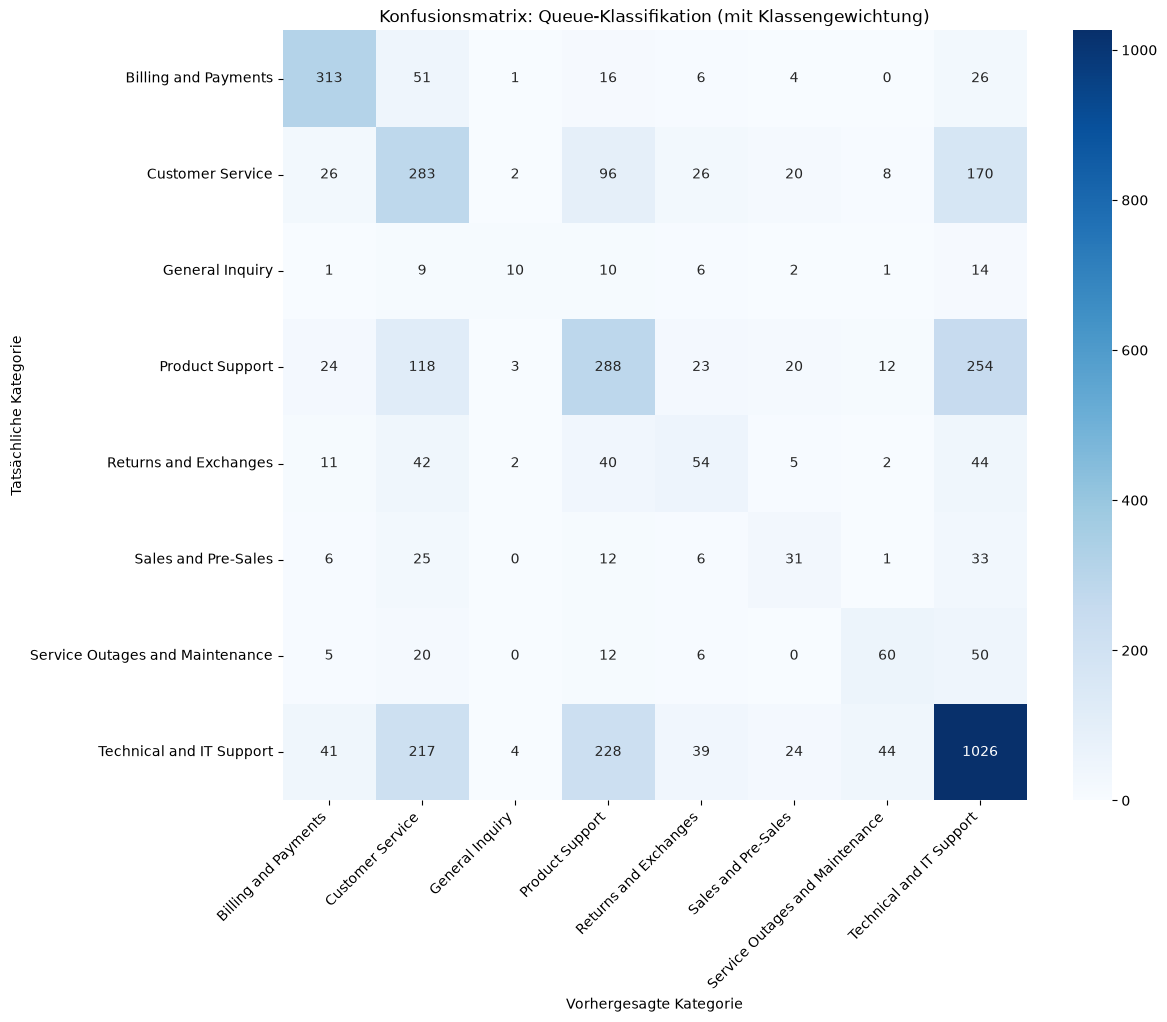

In [14]:
# Konfusionsmatrix des gewichteten Modells zum direkten Vergleich mit dem
# ungewichteten, überarbeiteten Modell.
cm_weighted = confusion_matrix(y_test_c, y_pred_w)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_weighted,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le_queue_clean.classes_,
    yticklabels=le_queue_clean.classes_
)
plt.title('Konfusionsmatrix: Queue-Klassifikation (mit Klassengewichtung)')
plt.ylabel('Tatsächliche Kategorie')
plt.xlabel('Vorhergesagte Kategorie')
plt.xticks(rotation=45, ha='right')
plt.show()

### Einordnung der Gewichtung

Der aussagekräftigste Vergleichsmaßstab ist hier nicht die Gesamtaccuracy, sondern der
makro-gemittelte F1-Wert, da dieser jede Klasse unabhängig von ihrer Häufigkeit gleich gewichtet und
somit die Behandlung der seltenen Kategorien sichtbar macht. Zu erwarten ist, dass die Gewichtung den
Recall der schwach besetzten Klassen spürbar anhebt, während die Precision der vormals dominanten
Kategorie *Technical and IT Support* leicht zurückgeht, weil das Modell seltener pauschal auf diese
Klasse ausweicht. Eine geringfügig niedrigere Gesamtaccuracy bei zugleich höherem makro-F1 ist in
diesem Kontext kein Rückschritt, sondern Ausdruck einer ausgewogeneren Vorhersage über alle Klassen
hinweg.

Bleiben einzelne Kategorien, etwa *Customer Service* und *Product Support*, auch nach der Gewichtung schwach und verwechseln sich ausweislich der Konfusionsmatrix vorrangig untereinander oder mit
*Technical and IT Support*, so wäre als weiterführender Schritt eine erneute, inhaltlich begründete
Bündelung dieser Kategorien zu erwägen oder, als invasivere Alternative, ein Resampling-Verfahren auf
den Embeddings zu prüfen.

## Wechsel zu einem mehrsprachigen Embedding-Modell

Die bisherigen Repräsentationen wurden mit `all-MiniLM-L6-v2` erzeugt, einem kompakten, jedoch
überwiegend auf englischsprachigen Texten trainierten Modell. Da der zugrunde liegende Datensatz
ausdrücklich mehrsprachig ist, besteht der Verdacht, dass die Embeddings für nicht-englische Tickets
nur unscharf zwischen den Kategorien trennen und damit eine obere Schranke für die erreichbare
Modellgüte setzen, die sich durch nachgelagerte Eingriffe wie Gewichtung oder Hyperparameterwahl
nicht überwinden lässt. Anders als die vorherigen Schritte, die am Ende der Verarbeitungskette
ansetzten, adressiert dieser Eingriff die Merkmalsbildung selbst.

Verwendet wird `paraphrase-multilingual-MiniLM-L12-v2`, das mehr als fünfzig Sprachen abdeckt und
dieselbe Embedding-Dimension von 384 besitzt wie das bisherige Modell. Dadurch bleibt die übrige
Pipeline unverändert, und ein etwaiger Zugewinn ist eindeutig dem Wechsel der Textrepräsentation
zuzuschreiben. Sämtliche weiteren Einstellungen, unter anderem Kategorieschema, Klassengewichtung, Split-Verfahren und Hyperparameter, werden bewusst beibehalten, um einen kontrollierten Vergleich zu gewährleisten.

In [15]:
# Mehrsprachiges Embedding-Modell derselben Architekturfamilie laden. Seine
# Ausgabedimension von 384 entspricht jener des zuvor genutzten Modells, sodass
# die nachgelagerte Verarbeitung unverändert bleibt.
multilingual_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Die Einbettung erfolgt auf dem bereinigten Datensatz, der die zuvor gebildete
# Spalte mit dem zusammengeführten Text aus Betreff und Nachrichtentext bereits
# enthält. Dadurch bleibt die Zuordnung zwischen den Merkmalen und der Zielvariable
# über die Zeilenreihenfolge von df_clean erhalten.
texts_clean = df_clean['text_feature'].tolist()

embeddings_multiling = multilingual_model.encode(
    texts_clean,
    batch_size=256,
    show_progress_bar=True
)
embeddings_multiling = np.asarray(embeddings_multiling)

print("Form der mehrsprachigen Embeddings:", embeddings_multiling.shape)

Batches: 100%|██████████| 77/77 [11:51<00:00,  9.24s/it]

Form der mehrsprachigen Embeddings: (19662, 384)


In [16]:
# Identisches Vorgehen wie beim gewichteten Modell, jedoch auf Basis der
# mehrsprachigen Embeddings. Die Zielvariable y_clean wurde bereits zuvor
# aus df_clean kodiert und kann unverändert weiterverwendet werden.
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    embeddings_multiling,
    y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)

# Klassengewichte erneut ausschließlich aus der Trainingsmenge ableiten.
classes_m, counts_m = np.unique(y_train_m, return_counts=True)
n_samples_m = len(y_train_m)
n_classes_m = len(classes_m)
class_weight_m = {cls: n_samples_m / (n_classes_m * cnt) for cls, cnt in zip(classes_m, counts_m)}
sample_weight_m = np.array([class_weight_m[label] for label in y_train_m])

# Unveränderte Modellkonfiguration für einen fairen Vergleich.
xgb_multiling_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    objective='multi:softprob',
    n_jobs=-1,
    random_state=42
)

print("Training auf mehrsprachigen Embeddings läuft...")
xgb_multiling_model.fit(X_train_m, y_train_m, sample_weight=sample_weight_m)

y_pred_m = xgb_multiling_model.predict(X_test_m)

print("\nClassification Report (mehrsprachige Embeddings, mit Gewichtung):")
print(classification_report(y_test_m, y_pred_m, target_names=le_queue_clean.classes_))

Training auf mehrsprachigen Embeddings läuft...

Classification Report (mehrsprachige Embeddings, mit Gewichtung):
                                 precision    recall  f1-score   support

           Billing and Payments       0.77      0.77      0.77       417
               Customer Service       0.41      0.47      0.44       631
                General Inquiry       0.47      0.17      0.25        53
                Product Support       0.43      0.44      0.43       742
          Returns and Exchanges       0.39      0.28      0.32       200
            Sales and Pre-Sales       0.28      0.22      0.25       114
Service Outages and Maintenance       0.50      0.42      0.46       153
       Technical and IT Support       0.65      0.66      0.66      1623

                       accuracy                           0.55      3933
                      macro avg       0.49      0.43      0.45      3933
                   weighted avg       0.55      0.55      0.55      3933



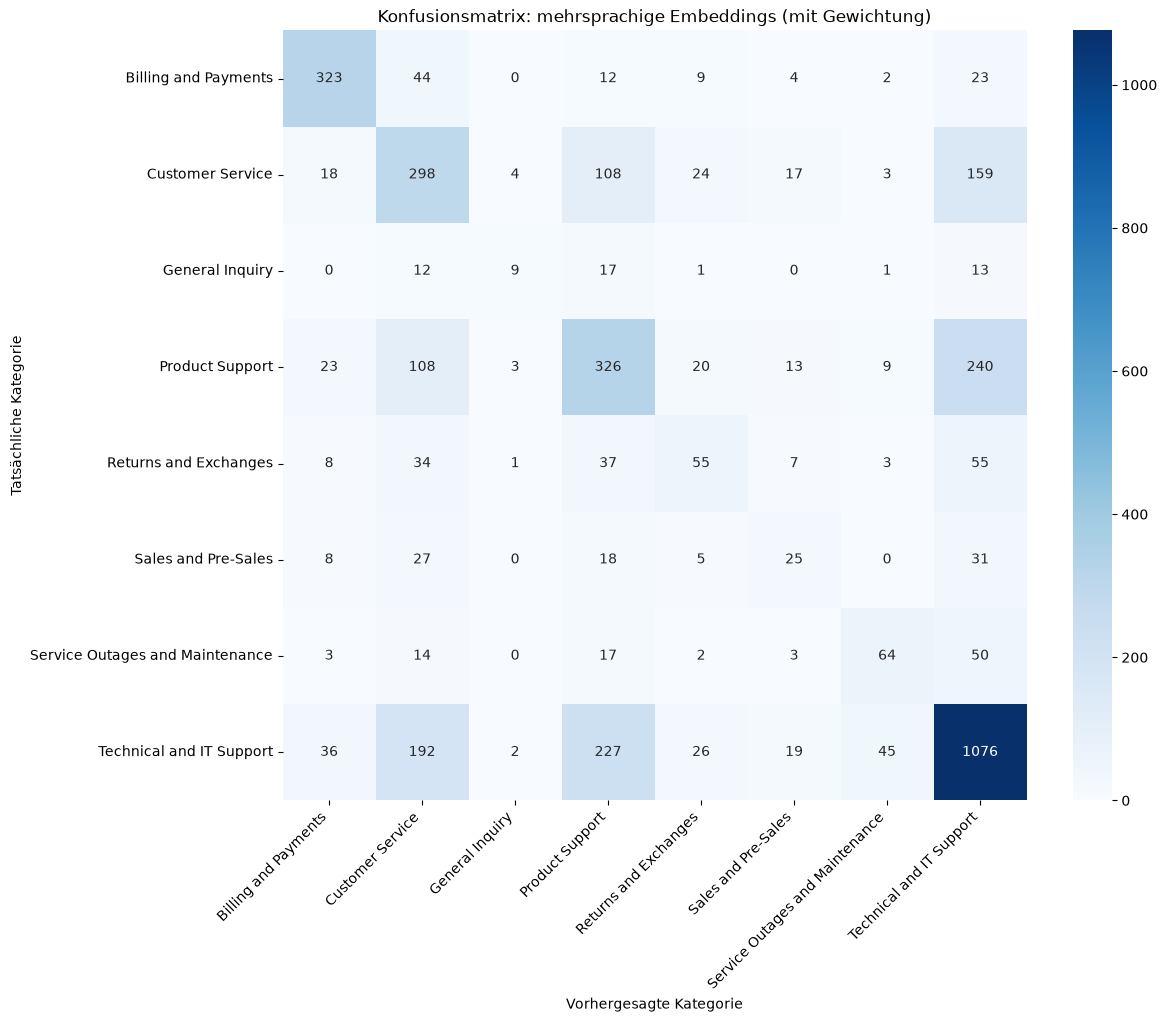

In [17]:
# Konfusionsmatrix des Modells auf mehrsprachigen Embeddings.
cm_multiling = confusion_matrix(y_test_m, y_pred_m)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_multiling,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le_queue_clean.classes_,
    yticklabels=le_queue_clean.classes_
)
plt.title('Konfusionsmatrix: mehrsprachige Embeddings (mit Gewichtung)')
plt.ylabel('Tatsächliche Kategorie')
plt.xlabel('Vorhergesagte Kategorie')
plt.xticks(rotation=45, ha='right')
plt.show()

### Einordnung des Modellwechsels

Maßgeblich für die Bewertung bleibt der makro-gemittelte F1-Wert im Vergleich zum vorangegangenen Lauf
auf den englischsprachig geprägten Embeddings. Fällt dieser Wert nun deutlich höher aus, bestätigt sich
die Vermutung, dass die zuvor beobachtete Leistungsgrenze maßgeblich aus einer unzureichenden
Repräsentation nicht-englischer Tickets resultierte; die schärfer getrennten Kategorien sollten sich
dann auch in einer ausgeprägteren Diagonale der Konfusionsmatrix niederschlagen. Bleibt der Zugewinn
hingegen gering, spräche dies dafür, dass die begrenzende Ursache nicht in der Sprache, sondern in der
inhaltlichen Überschneidung einzelner Kategorien liegt, insbesondere zwischen *Customer Service*, *Product Support* und *Technical and IT Support*, sodass eine weitere, empirisch durch die Konfusionsmatrix gestützte Bündelung dieser Klassen zum naheliegenden nächsten Schritt würde.

## Einsatz eines kapazitätsstärkeren mehrsprachigen Modells

Der Wechsel auf ein mehrsprachiges Embedding hat über sämtliche Kategorien hinweg zu einer
Verbesserung geführt, was die Bedeutung einer sprachadäquaten Textrepräsentation bestätigt. Die
verbleibende Schwäche konzentriert sich nun auf die inhaltlich eng benachbarten Kategorien *Customer
Service*, *Product Support* und *Technical and IT Support*. Bevor diese Überschneidung durch eine
weitere Bündelung und damit unter Verzicht auf Granularität aufgelöst wird, ist zu klären, welcher
Anteil der Restschwäche auf die begrenzte Kapazität des bislang verwendeten, kompakten Modells
zurückgeht.

Hierzu wird `paraphrase-multilingual-mpnet-base-v2` herangezogen, das auf der mpnet-Architektur
beruht und Embeddings mit 768 Dimensionen erzeugt. Anders als der vorherige Schritt handelt es sich
somit nicht um einen reinen Austausch bei gleicher Merkmalsbreite: Sowohl die zugrunde liegende
Architektur als auch die Dimensionalität ändern sich. Der nachgelagerte Klassifikator ist gegenüber
der Merkmalsbreite unempfindlich, sodass die Pipeline unverändert bleibt; bei der Interpretation ist
jedoch zu berücksichtigen, dass ein etwaiger Zugewinn der gesteigerten Modellkapazität insgesamt und
nicht einer einzelnen, isolierten Stellgröße zuzuschreiben ist. Split-Verfahren, Klassengewichtung und
Hyperparameter des Klassifikators werden erneut beibehalten.

In [18]:
# Kapazitätsstärkeres mehrsprachiges Modell auf Basis der mpnet-Architektur. Seine
# Ausgabedimension beträgt 768, weshalb die Einbettung entsprechend rechenintensiver
# ausfällt als bei den zuvor verwendeten Modellen.
mpnet_model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')

# Auch hier wird der zusammengeführte Text aus Betreff und Nachrichtentext des
# bereinigten Datensatzes eingebettet, sodass die Zuordnung zur bereits kodierten
# Zielvariable y_clean gewahrt bleibt.
texts_clean = df_clean['text_feature'].tolist()

embeddings_mpnet = mpnet_model.encode(
    texts_clean,
    batch_size=128,
    show_progress_bar=True
)
embeddings_mpnet = np.asarray(embeddings_mpnet)

print("Form der mpnet-Embeddings:", embeddings_mpnet.shape)

Batches: 100%|██████████| 154/154 [37:06<00:00, 14.46s/it]

Form der mpnet-Embeddings: (19662, 768)


In [19]:
# Identisches Vorgehen wie zuvor, nun auf den mpnet-Embeddings.
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    embeddings_mpnet,
    y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)

# Klassengewichte erneut ausschließlich aus der Trainingsmenge ableiten.
classes_p, counts_p = np.unique(y_train_p, return_counts=True)
n_samples_p = len(y_train_p)
n_classes_p = len(classes_p)
class_weight_p = {cls: n_samples_p / (n_classes_p * cnt) for cls, cnt in zip(classes_p, counts_p)}
sample_weight_p = np.array([class_weight_p[label] for label in y_train_p])

# Unveränderte Modellkonfiguration für einen kontrollierten Vergleich.
xgb_mpnet_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    objective='multi:softprob',
    n_jobs=-1,
    random_state=42
)

print("Training auf mpnet-Embeddings läuft...")
xgb_mpnet_model.fit(X_train_p, y_train_p, sample_weight=sample_weight_p)

y_pred_p = xgb_mpnet_model.predict(X_test_p)

print("\nClassification Report (mpnet-Embeddings, mit Gewichtung):")
print(classification_report(y_test_p, y_pred_p, target_names=le_queue_clean.classes_))

Training auf mpnet-Embeddings läuft...

Classification Report (mpnet-Embeddings, mit Gewichtung):
                                 precision    recall  f1-score   support

           Billing and Payments       0.75      0.79      0.77       417
               Customer Service       0.41      0.47      0.44       631
                General Inquiry       0.61      0.21      0.31        53
                Product Support       0.48      0.43      0.46       742
          Returns and Exchanges       0.49      0.34      0.40       200
            Sales and Pre-Sales       0.42      0.29      0.34       114
Service Outages and Maintenance       0.49      0.46      0.47       153
       Technical and IT Support       0.65      0.69      0.67      1623

                       accuracy                           0.57      3933
                      macro avg       0.54      0.46      0.48      3933
                   weighted avg       0.57      0.57      0.57      3933



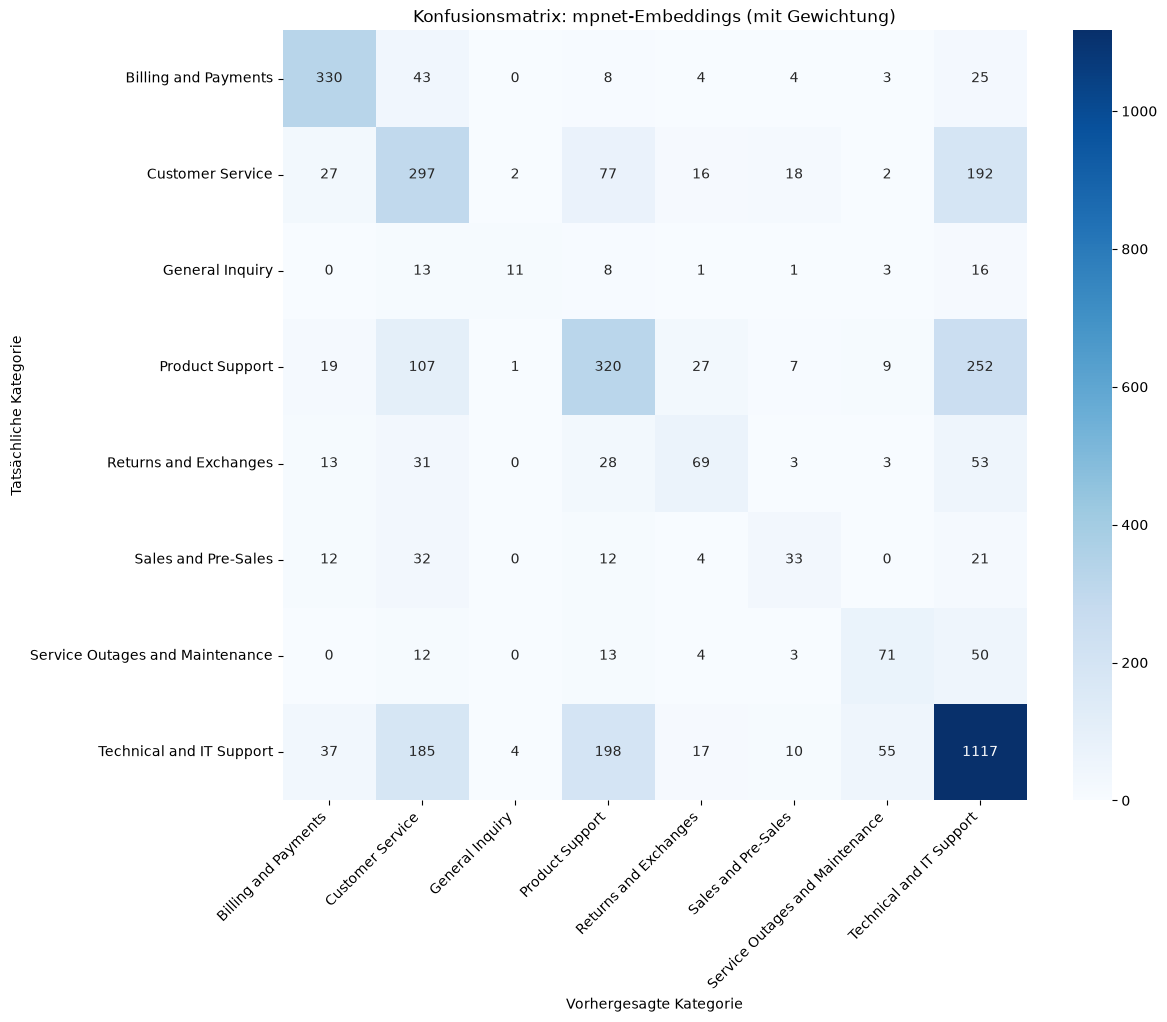

In [20]:
# Konfusionsmatrix des mpnet-basierten Modells.
cm_mpnet = confusion_matrix(y_test_p, y_pred_p)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_mpnet,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le_queue_clean.classes_,
    yticklabels=le_queue_clean.classes_
)
plt.title('Konfusionsmatrix: mpnet-Embeddings (mit Gewichtung)')
plt.ylabel('Tatsächliche Kategorie')
plt.xlabel('Vorhergesagte Kategorie')
plt.xticks(rotation=45, ha='right')
plt.show()

### Einordnung des Kapazitätswechsels

Der Vergleich des makro-gemittelten F1-Werts mit dem Lauf auf den kleineren mehrsprachigen Embeddings
erlaubt eine Aussage darüber, ob die zuvor verbliebene Schwäche maßgeblich aus der begrenzten
Modellkapazität resultierte. Ein deutlicher Zugewinn, insbesondere bei den eng benachbarten
Kategorien *Customer Service* und *Product Support*, spräche dafür, dass das stärkere Modell feinere
semantische Unterschiede auflöst und eine weitere Bündelung dieser Klassen vorerst nicht erforderlich
ist. Verbleibt die Verwechslung zwischen diesen Kategorien hingegen auch bei gesteigerter Kapazität,
so ist davon auszugehen, dass die Grenze nicht in der Repräsentation, sondern in einer tatsächlichen
inhaltlichen Überlappung der Kategorien selbst liegt, was einen Befund darstellt, der die Zusammenführung dieser Klassen dann nicht als Notlösung, sondern als sachlich gebotene Bereinigung des Zielschemas
ausweist.

Unabhängig vom Ausgang ist abzuwägen, dass der Kapazitätsgewinn mit einem erhöhten Rechenaufwand bei
der Einbettung und einer verdoppelten Merkmalsdimension einhergeht, was für einen produktiven Einsatz
gegen den erzielten Genauigkeitsgewinn abzuwägen wäre.

## Abschließende Interpretation

Der Übergang auf das kapazitätsstärkere mpnet-Modell führt zu einer maßvollen, aber durchgängigen
Verbesserung: Der makro-gemittelte F1-Wert steigt auf 0,50, getragen vor allem von einer höheren
makro-Precision von 0,54, während die gewichteten Kennzahlen mit jeweils 0,57 auf dem Niveau des
vorangegangenen mehrsprachigen Modells verharren. Die gesteigerte Kapazität schärft somit primär die
Trennschärfe der ohnehin gut erkennbaren Kategorien, ohne die Gesamtleistung sprunghaft anzuheben.
Erkennbar profitieren die klar umrissenen Klassen: *Billing and Payments* erreicht mit einem F1-Wert
von 0,79 den höchsten Wert, gefolgt von *Technical and IT Support* mit 0,66, was die inhaltliche
Eigenständigkeit dieser Anliegen widerspiegelt.

Die entscheidende Beobachtung betrifft jedoch die weiterhin schwachen Kategorien *Customer Service*
(F1 0,45) und *Product Support* (F1 0,47), deren Werte sich auch unter dem stärkeren Modell nur
geringfügig verändern. Dass selbst eine deutlich erhöhte Modellkapazität diese beiden Klassen nicht
aufzulösen vermag, bestätigt die zuvor formulierte Vermutung: Die verbleibende Schwäche resultiert
nicht aus einer unzureichenden Textrepräsentation, sondern aus einer tatsächlichen inhaltlichen
Überlappung der Kategorien, die sich aus den Anfragetexten allein nicht zuverlässiger trennen lässt.
Ergänzend zeigt sich an *Sales and Pre-Sales* (F1 0,31) und *General Inquiry* (F1 0,41), dass die
sehr schwach besetzten Klassen trotz der Gewichtung an ihrer geringen Datengrundlage leiden.

In der Gesamtschau dokumentiert die Entwicklung von der Baseline bis zum vorliegenden Modell einen
konsistenten Erkenntnisgewinn, da die aufeinander aufbauenden Eingriffe, namentlich die Bereinigung
des Kategorieschemas, der Ausgleich des Klassenungleichgewichts und die sukzessive Verbesserung der
Textrepräsentation, jeweils einen nachweisbaren und sachlich begründeten Beitrag geleistet und die
Leistungsgrenzen schrittweise verschoben haben. Dass sich die Genauigkeit nun bei etwa 0,57 einpendelt,
ist weniger Ausdruck eines methodischen Defizits als der inhärenten Mehrdeutigkeit realer
Kundenanfragen, deren Zuordnung zu einer einzelnen Warteschlange selbst für menschliche
Bearbeitende nicht stets eindeutig ausfällt. Für eine weitergehende Steigerung kämen daher in erster
Linie eine inhaltlich begründete Zusammenführung der überlappenden Kategorien *Customer Service* und
*Product Support* sowie, als methodisch aufwendigere Alternative, ein direkt auf die
Klassifikationsaufgabe feinabgestimmtes Sprachmodell in Betracht.

## Hyperparameter-Optimierung mittels Grid Search

Bevor das Zeitverhalten des Verfahrens vermessen wird, ist zu klären, welche Konfiguration des
Modells dieser Messung zugrunde liegen soll, weshalb an dieser Stelle untersucht wird, ob sich die
Klassifikationsgüte durch eine systematische Abstimmung der Hyperparameter über das bislang erreichte
Niveau hinaus steigern lässt. Die bislang
verwendeten Einstellungen wurden bewusst über alle Ausbaustufen hinweg konstant gehalten, um die
Wirkung der einzelnen Eingriffe isoliert beurteilen zu können. Nachdem diese Vergleiche abgeschlossen
sind, ist es folgerichtig zu prüfen, welches Leistungsniveau bei sorgfältig gewählten Parametern
erreichbar ist, und damit zugleich, ob die zuvor beobachtete Leistungsgrenze noch auf eine
suboptimale Konfiguration oder bereits auf die inhaltliche Überlappung der Kategorien zurückzuführen
ist. Die auf diese Weise bestimmte Konfiguration bildet zugleich die Grundlage der anschließenden
Zeitmessung.

Die Suche wird ausschließlich auf den Trainingsdaten durchgeführt und stützt sich auf eine
geschichtete Kreuzvalidierung, sodass die Testmenge unberührt bleibt und ihre Rolle als unabhängige
Bewertungsgrundlage gewahrt ist. Als Zielgröße der Optimierung dient der makro-gemittelte F1-Wert,
weil dieser jede Kategorie unabhängig von ihrer Häufigkeit gleich gewichtet und damit derselben
Bewertungslogik folgt, die bereits die vorangegangene Ausbalancierung des Klassenungleichgewichts
geleitet hat. Eine Optimierung nach der Gesamtgenauigkeit würde demgegenüber die schwach besetzten
Kategorien erneut hinter der dominierenden Klasse zurücktreten lassen und stünde in Widerspruch zu
der zuvor getroffenen methodischen Ausrichtung. Der Suchraum ist bewusst schlank gehalten und die Zahl der
Faltungen maßvoll bemessen, damit die Rechenzeit auf einer prozessorbasierten Ausführung beherrschbar
bleibt, wobei die Parallelisierung allein der übergeordneten Suche überlassen wird, um die
verfügbaren Rechenkerne wirksam auszunutzen.

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Der Suchraum umfasst die wirkungsstaerksten Stellgroessen eines Gradient-Boosting-Modells:
# Die Anzahl der Baeume und die Lernrate bestimmen gemeinsam die Anpassungsfaehigkeit des
# Modells, die maximale Baumtiefe reguliert die Komplexitaet der einzelnen Baeume, und der
# Zeilenanteil je Baum wirkt einer uebermaessigen Anpassung an die Trainingsdaten entgegen.
# Der Raum ist bewusst schlank gehalten und ergibt in der Kombination seiner Werte zwoelf
# zu pruefende Konfigurationen.
param_grid = {
    'n_estimators': [200],  #[200, 400]
    'learning_rate': [0.05], #[0.05, 0.1]
    'max_depth': [5],        #4 oder 5 oder 6
    'subsample': [1.0]      #0,8 hat zu lange gedauert...
}

# Basis-Schaetzer ohne die zu optimierenden Parameter, die von der Gittersuche gesetzt werden.
# Die Parallelisierung wird bewusst nicht auf der Ebene des einzelnen Modells angesiedelt,
# sondern der uebergeordneten Suche ueberlassen, weshalb der Schaetzer hier auf einen Kern
# beschraenkt wird. Auf diese Weise werden die verschiedenen Konfigurationen echt nebenlaeufig
# trainiert, ohne dass beide Ebenen um dieselben Recheneinheiten konkurrieren.
base_model = XGBClassifier(
    objective='multi:softprob',
    n_jobs=1,
    random_state=42
)

# Geschichtete Aufteilung in drei Faltungen, sodass in jeder Faltung die Klassenverteilung
# erhalten bleibt und auch seltene Kategorien vertreten sind. Drei Faltungen bilden einen
# tragfaehigen Kompromiss zwischen der Verlaesslichkeit der Schaetzung und der Rechenzeit.
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Die Gittersuche optimiert den makro-gemittelten F1-Wert und parallelisiert ueber alle
# verfuegbaren Kerne. Die Bewertung erfolgt ausschliesslich innerhalb der Kreuzvalidierung
# auf den Trainingsdaten, sodass die Testmenge unberuehrt bleibt.
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print("Gittersuche laeuft...")
grid_search.fit(X_train_p, y_train_p, sample_weight=sample_weight_p)

print("\nBeste gefundene Konfiguration:")
for name, value in grid_search.best_params_.items():
    print(f"  {name}: {value}")
print(f"\nBester makro-F1 in der Kreuzvalidierung: {grid_search.best_score_:.3f}")

Gittersuche laeuft...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Beste gefundene Konfiguration:
  learning_rate: 0.05
  max_depth: 5
  n_estimators: 200
  subsample: 1.0

Bester makro-F1 in der Kreuzvalidierung: 0.447


In [22]:
# Das durch die Gittersuche bestimmte Modell wird auf der unberuehrten Testmenge bewertet,
# um seine Guete an unabhaengigen Daten zu pruefen und mit den vorangegangenen Laeufen
# vergleichbar zu machen.
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_p)

print("Classification Report (optimiertes Modell, Testmenge):")
print(classification_report(y_test_p, y_pred_best, target_names=le_queue_clean.classes_))

Classification Report (optimiertes Modell, Testmenge):
                                 precision    recall  f1-score   support

           Billing and Payments       0.69      0.79      0.74       417
               Customer Service       0.40      0.43      0.42       631
                General Inquiry       0.29      0.26      0.27        53
                Product Support       0.42      0.38      0.40       742
          Returns and Exchanges       0.33      0.41      0.37       200
            Sales and Pre-Sales       0.28      0.38      0.32       114
Service Outages and Maintenance       0.36      0.51      0.42       153
       Technical and IT Support       0.66      0.59      0.62      1623

                       accuracy                           0.52      3933
                      macro avg       0.43      0.47      0.44      3933
                   weighted avg       0.53      0.52      0.52      3933



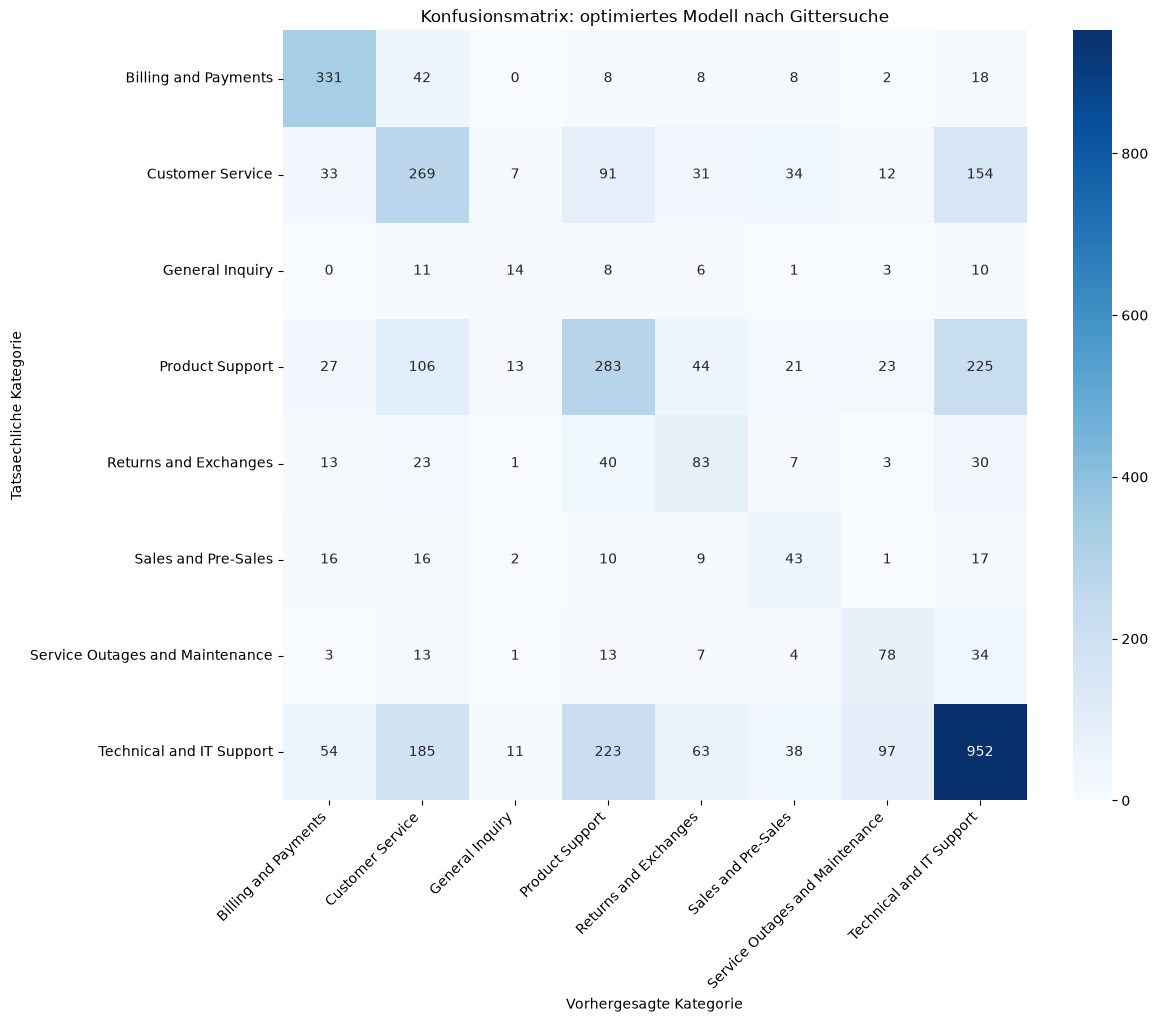

In [23]:
# Konfusionsmatrix des optimierten Modells zum abschliessenden Vergleich.
cm_best = confusion_matrix(y_test_p, y_pred_best)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_best,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le_queue_clean.classes_,
    yticklabels=le_queue_clean.classes_
)
plt.title('Konfusionsmatrix: optimiertes Modell nach Gittersuche')
plt.ylabel('Tatsaechliche Kategorie')
plt.xlabel('Vorhergesagte Kategorie')
plt.xticks(rotation=45, ha='right')
plt.show()

### Einordnung der Optimierung

Der Vergleich des optimierten Modells mit der zuvor verwendeten Konfiguration erlaubt eine Aussage
darüber, wie viel Leistungsreserve in der Wahl der Hyperparameter verborgen lag. Fällt der Zugewinn
im makro-gemittelten F1-Wert gering aus, so bestätigt dies die im vorangegangenen Kapitel formulierte
Deutung, wonach die verbleibende Schwäche nicht aus einer unzureichenden Modellkonfiguration, sondern
aus der inhaltlichen Überlappung einzelner Kategorien erwächst, die sich aus den Anfragetexten allein
nicht schärfer trennen lassen. Ein solcher Befund ist keineswegs als Misserfolg der Optimierung zu
werten, sondern untermauert die zentrale Erkenntnis des gesamten Prototyps, dass die erreichte
Leistungsgrenze wesentlich in der Beschaffenheit der Daten und des Zielschemas begründet liegt.
Sollte sich hingegen ein spürbarer Zuwachs zeigen, wäre die optimierte Konfiguration als finale
Ausbaustufe des Modells zu übernehmen. Unabhängig vom Ausmaß des Zugewinns bildet die hier bestimmte
Konfiguration die Grundlage der im folgenden Kapitel vorgenommenen Zeitmessung, sodass sich diese auf
das endgültige Modell bezieht.

## Erfassung von Trainings- und Inferenzzeit

Damit der maschinelle Lernansatz den beiden LLM-basierten Verfahren nicht allein hinsichtlich der
Klassifikationsgüte, sondern auch bezüglich seines Zeitverhaltens gegenübergestellt werden kann,
werden im Folgenden die Trainingsdauer sowie die Verarbeitungszeit je Ticket erhoben. Die Messung
orientiert sich methodisch an der in den LLM-Notebooks verwendeten Vorgehensweise, sodass die
gewonnenen Kennzahlen unmittelbar vergleichbar bleiben, wobei die pro Ticket ausgewiesene Latenz dort
über eine hochauflösende Zeitmessung um den eigentlichen Klassifikationsaufruf herum bestimmt wird.

Eine begriffliche Präzisierung ist an dieser Stelle geboten, weil die Klassifikation eines Tickets im
vorliegenden Ansatz aus zwei getrennten Verarbeitungsschritten besteht. Zunächst wird der
zusammengeführte Text in eine Vektorrepräsentation überführt, und erst anschließend trifft der
trainierte Klassifikator seine Entscheidung. Da die LLM-Ansätze pro Ticket einen einzigen, den
gesamten Vorgang umfassenden Aufruf messen, wird auch hier die Gesamtlatenz von der Einbettung bis
zur fertigen Vorhersage erfasst, um eine methodisch faire Entsprechung herzustellen. Ergänzend werden
die Anteile der Einbettung und der eigentlichen Klassifikatorvorhersage getrennt ausgewiesen, da der
zeitliche Aufwand im Regelfall nahezu vollständig auf die Erzeugung der Embeddings entfällt und diese
Aufschlüsselung für die spätere Einordnung der Ergebnisse aufschlussreich ist.

### Trainingszeit des finalen Modells

Erfasst wird die reine Zeit, die das Anpassen des Klassifikators auf den bereits eingebetteten
Trainingsdaten in Anspruch nimmt. Die Berechnung der Embeddings zählt bewusst nicht zur
Trainingszeit, da sie einen vorgelagerten, einmaligen Vorbereitungsschritt darstellt und nicht Teil
des eigentlichen Lernvorgangs ist. Herangezogen wird das finale Modell, das auf den mpnet-Embeddings beruht und dessen Hyperparameter
aus der zuvor durchgeführten Gittersuche stammen, sodass sich die Messung auf die abschließende
Ausbaustufe des Prototyps bezieht.

In [24]:
import time

# Fuer die Zeitmessung wird die durch die Gittersuche als beste ermittelte Konfiguration
# herangezogen, sodass sich Trainings- und Inferenzzeit auf genau jene Modellvariante
# beziehen, die die abschliessende Ausbaustufe des Prototyps bildet. Der Klassifikator wird
# hierfuer mit den optimalen Parametern und denselben Stichprobengewichten neu angelegt.
xgb_final_model = XGBClassifier(
    **grid_search.best_params_,
    objective='multi:softprob',
    n_jobs=-1,
    random_state=42
)

# Die Trainingszeit wird ueber eine hochaufloesende Zeitmessung unmittelbar um den
# Anpassungsvorgang herum bestimmt. Erfasst wird ausschliesslich das Training des
# Klassifikators auf den bereits vorliegenden Embeddings, nicht deren vorgelagerte Berechnung.
train_start = time.perf_counter()
xgb_final_model.fit(X_train_p, y_train_p, sample_weight=sample_weight_p)
train_time = time.perf_counter() - train_start

print(f"Trainingszeit des Klassifikators: {train_time:.2f} s")
print(f"Trainingsbeispiele              : {len(y_train_p)}")

Trainingszeit des Klassifikators: 197.00 s
Trainingsbeispiele              : 15729


### Inferenzzeit je Ticket

Zur Bestimmung der Verarbeitungszeit je Ticket wird für jedes Element der Testmenge die vollständige
Verarbeitungskette durchlaufen, die sich aus der Einbettung des Textes und der anschließenden
Vorhersage durch den Klassifikator zusammensetzt. Für jedes Ticket werden die Gesamtlatenz sowie die
beiden Teilzeiten getrennt festgehalten, sodass sich sowohl eine mit den LLM-Ansätzen vergleichbare
Gesamtkennzahl als auch eine Aufschlüsselung der Zeitanteile ergibt. Die Verarbeitung erfolgt bewusst
einzeln und nicht stapelweise, da auch die LLM-Ansätze jedes Ticket als eigenständige Anfrage
behandeln und nur so eine unverzerrte Entsprechung der Latenz je Ticket entsteht.

In [25]:
# Die Texte der Testmenge werden aus dem bereinigten Datensatz anhand der beim Split
# entstandenen Indizes rekonstruiert, damit die zeitlich gemessene Verarbeitung auf
# denselben Tickets erfolgt, die auch der Guetebewertung zugrunde lagen.
_, test_idx = train_test_split(
    np.arange(len(y_clean)),
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)
test_texts = df_clean.iloc[test_idx]['text_feature'].tolist()

# Fuer jedes Ticket werden die Einbettungszeit und die Vorhersagezeit einzeln erfasst.
# Die Summe beider Anteile bildet die Gesamtlatenz, die den je Ticket gemessenen
# Latenzen der LLM-Ansaetze entspricht.
embed_times = []
predict_times = []
total_times = []

for text in test_texts:
    t0 = time.perf_counter()
    vec = mpnet_model.encode([text])
    t1 = time.perf_counter()
    xgb_final_model.predict(vec)
    t2 = time.perf_counter()

    embed_times.append(t1 - t0)
    predict_times.append(t2 - t1)
    total_times.append(t2 - t0)

print(f"Vermessene Tickets: {len(total_times)}")

Vermessene Tickets: 3933


In [26]:
import statistics

# Aus den je Ticket gemessenen Gesamtlatenzen werden dieselben Kennzahlen gebildet, die
# auch in den LLM-Notebooks berichtet werden, sodass ein unmittelbarer Vergleich moeglich ist.
mittel = statistics.mean(total_times)
median = statistics.median(total_times)
p95 = sorted(total_times)[int(0.95 * len(total_times)) - 1]
minimum = min(total_times)
maximum = max(total_times)

print("Inferenzlatenz je Ticket (Einbettung und Vorhersage zusammen)")
print("-" * 60)
print(f"Mittelwert   : {mittel*1000:.1f} ms")
print(f"Median       : {median*1000:.1f} ms")
print(f"95-Perzentil : {p95*1000:.1f} ms")
print(f"Min / Max    : {minimum*1000:.1f} ms / {maximum*1000:.1f} ms")
print()

# Getrennte Ausweisung der beiden Teilschritte, um den dominierenden Zeitanteil sichtbar
# zu machen.
print("Aufschluesselung der mittleren Zeitanteile je Ticket")
print("-" * 60)
print(f"Einbettung   : {statistics.mean(embed_times)*1000:.1f} ms")
print(f"Vorhersage   : {statistics.mean(predict_times)*1000:.1f} ms")
print()

# Hochrechnung der Gesamtlatenz auf den vollstaendigen Datensatz, ausgedrueckt in
# Sekunden und Minuten, analog zur Darstellung im lokalen LLM-Ansatz.
zeit_pro_ticket = mittel
hochrechnung_s = zeit_pro_ticket * len(df_multilingual)
print(f"Mittlere Zeit je Ticket           : {zeit_pro_ticket*1000:.1f} ms")
print(f"Hochrechnung {len(df_multilingual)} Tickets : "
      f"{hochrechnung_s:.0f} s  (~{hochrechnung_s/60:.1f} min)")

Inferenzlatenz je Ticket (Einbettung und Vorhersage zusammen)
------------------------------------------------------------
Mittelwert   : 150.0 ms
Median       : 151.8 ms
95-Perzentil : 206.2 ms
Min / Max    : 63.7 ms / 398.6 ms

Aufschluesselung der mittleren Zeitanteile je Ticket
------------------------------------------------------------
Einbettung   : 148.0 ms
Vorhersage   : 2.1 ms

Mittlere Zeit je Ticket           : 150.0 ms
Hochrechnung 20000 Tickets : 3001 s  (~50.0 min)


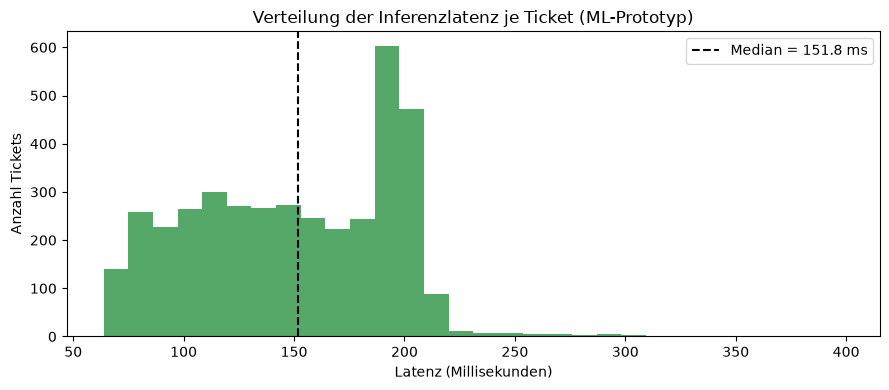

In [27]:
# Histogramm der Gesamtlatenz je Ticket mit eingezeichnetem Median, in Anlehnung an die
# Latenzdarstellung der LLM-Notebooks. Die Zeiten werden in Millisekunden aufgetragen.
total_ms = [t * 1000 for t in total_times]

plt.figure(figsize=(9, 4))
plt.hist(total_ms, bins=30, color="#55a868")
plt.axvline(median * 1000, color="black", linestyle="--",
            label=f"Median = {median*1000:.1f} ms")
plt.title("Verteilung der Inferenzlatenz je Ticket (ML-Prototyp)")
plt.xlabel("Latenz (Millisekunden)")
plt.ylabel("Anzahl Tickets")
plt.legend()
plt.tight_layout()
plt.show()

### Einordnung der Zeitmessung

Die erhobenen Kennzahlen sind im Zusammenhang mit den entsprechenden Werten der beiden LLM-Ansätze zu
lesen. Kennzeichnend für den maschinellen Lernansatz ist, dass sich der Aufwand in eine einmalige
Trainingsphase und eine sehr geringe Zeit je Einzelvorhersage aufteilt, wobei die Inferenzlatenz nach
aller Erwartung im Bereich weniger Millisekunden liegt und damit um Größenordnungen unter den
Antwortzeiten der sprachmodellbasierten Verfahren rangiert. Die getrennte Ausweisung der Zeitanteile
verdeutlicht überdies, dass der weitaus größte Teil dieser ohnehin kurzen Latenz auf die Erzeugung
der Einbettung entfällt, während die eigentliche Entscheidung des Klassifikators nahezu ohne
messbaren Aufwand erfolgt. Für eine abschließende Bewertung des Zeitverhaltens ist ferner zu
berücksichtigen, dass die hier gemessene Trainingszeit nur einmalig anfällt, wohingegen die
LLM-Ansätze bei jeder Klassifikation den vollen Verarbeitungsaufwand erneut erbringen.